<a href="https://colab.research.google.com/github/jivesh81/spam-ham/blob/main/spam_ham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Libraries loaded
Total messages: 5572


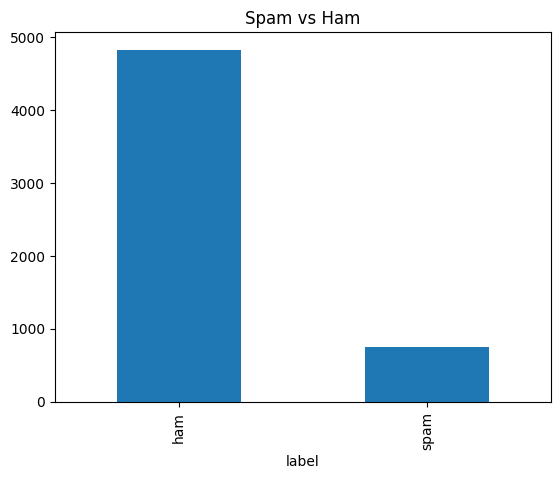

Iteration 1, loss = 0.62875401
Iteration 2, loss = 0.36738569
Iteration 3, loss = 0.17346397
Iteration 4, loss = 0.07962513
Iteration 5, loss = 0.03796962
Iteration 6, loss = 0.02037944
Iteration 7, loss = 0.01268901
Iteration 8, loss = 0.00851618
Iteration 9, loss = 0.00594413
Iteration 10, loss = 0.00452077
Iteration 11, loss = 0.00351609
Iteration 12, loss = 0.00280944
Iteration 13, loss = 0.00231725
Iteration 14, loss = 0.00192365
Iteration 15, loss = 0.00196934
Iteration 16, loss = 0.00143426
Iteration 17, loss = 0.00119708
Iteration 18, loss = 0.00104655
Iteration 19, loss = 0.00094910
Iteration 20, loss = 0.00083060
Iteration 21, loss = 0.00077526
Iteration 22, loss = 0.00070682
Iteration 23, loss = 0.00065492
Iteration 24, loss = 0.00059762
Iteration 25, loss = 0.00056623
Iteration 26, loss = 0.00053577
Iteration 27, loss = 0.00050671
Iteration 28, loss = 0.00047546
Iteration 29, loss = 0.00045380
Iteration 30, loss = 0.00043890
Iteration 31, loss = 0.00041408
Training loss did

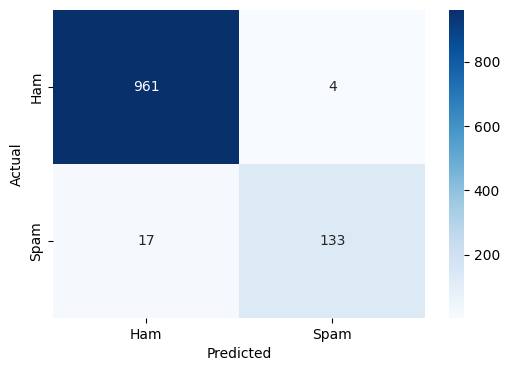

Model saved

Message   : Win 50000 now!!! Click here
Prediction: SPAM
Spam: 73.65%  |  Ham: 26.35%
----------------------------------------

Message   : Let's meet tomorrow
Prediction: HAM
Spam: 0.03%  |  Ham: 99.97%
----------------------------------------

Message   : URGENT! Your account is blocked
Prediction: SPAM
Spam: 84.32%  |  Ham: 15.68%
----------------------------------------

Message   : Send me notes please
Prediction: HAM
Spam: 0.06%  |  Ham: 99.94%
----------------------------------------

Enter your own messages (type 'quit' to exit)

Enter message: hello hi

Message   : hello hi
Prediction: HAM
Spam: 0.02%  |  Ham: 99.98%
----------------------------------------


In [ ]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from google.colab import drive
drive.mount('/content/drive')

nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded")

file_path = '/content/drive/MyDrive/scam data/spam.csv'
df = pd.read_csv(file_path, encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df['cleaned'] = df['message'].apply(clean_text)

print("Total messages:", len(df))

df['label'].value_counts().plot(kind='bar', title="Spam vs Ham")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'], df['label_num'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=100,
    verbose=True,
    random_state=42
)

model.fit(X_train_vec, y_train)
print("Model trained")

y_pred = model.predict(X_test_vec)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

joblib.dump(model, "/content/drive/MyDrive/spam_nn_model.pkl")
joblib.dump(vectorizer, "/content/drive/MyDrive/vectorizer.pkl")
print("Model saved")

def predict(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "SPAM" if result == 1 else "HAM"
    print("\nMessage   :", text)
    print("Prediction:", label)
    print(f"Spam: {round(prob[1]*100,2)}%  |  Ham: {round(prob[0]*100,2)}%")
    print("-" * 40)

predict("Win 50000 now!!! Click here")
predict("Let's meet tomorrow")
predict("URGENT! Your account is blocked")
predict("Send me notes please")

print("\nEnter your own messages (type 'quit' to exit)")
while True:
    user_input = input("\nEnter message: ").strip()
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("Exiting.")
        break
    if not user_input:
        print("Please enter a message.")
        continue
    predict(user_input)